In [ ]:
# ===== CELL 1 — Imports, seed, device, config =====
import time, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

QUICK_TEST = False           # True -> 2 epochs for a quick smoke test
EPOCHS = 2 if QUICK_TEST else 30
BATCH_SIZE = 128
CIFAR_CLASSES = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

In [14]:
# ===== CELL 2 — CIFAR-10 data: 45k/5k/10k split + loaders =====
MEAN, STD = (0.4914,0.4822,0.4465), (0.2470,0.2435,0.2616)
train_tf = T.Compose([T.RandomCrop(32,padding=4), T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize(MEAN,STD)])
eval_tf  = T.Compose([T.ToTensor(), T.Normalize(MEAN,STD)])

full_aug   = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
full_clean = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=eval_tf)
test_set   = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=eval_tf)

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(full_aug), generator=g).tolist()
train_set = Subset(full_aug, perm[:45000])
val_set   = Subset(full_clean, perm[45000:])

train_loader = DataLoader(train_set, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   256,        shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  256,        shuffle=False, num_workers=2, pin_memory=True)
print(f"train={len(train_set)} val={len(val_set)} test={len(test_set)}")

train=45000 val=5000 test=10000


In [15]:
# ===== CELL 3 — Utilities: param count, train, eval, plots, filters =====
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval(); correct=total=0; loss_sum=0.0
    for x,y in loader:
        x,y=x.to(device),y.to(device); out=model(x)
        if criterion is not None: loss_sum+=criterion(out,y).item()*x.size(0)
        correct+=(out.argmax(1)==y).sum().item(); total+=x.size(0)
    return correct/total, (loss_sum/total if criterion is not None else None)

def train_model(model, label, epochs=EPOCHS, lr=0.01, weight_decay=5e-4):
    set_seed(); model=model.to(device)
    crit=nn.CrossEntropyLoss()
    opt=torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay, nesterov=True)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    h={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'epoch_time':[],'label':label,'params':count_params(model)}
    print(f"\n=== {label} | params={h['params']:,} | epochs={epochs} | lr={lr} ===")
    for ep in range(epochs):
        model.train(); t0=time.time(); rl=rc=rt=0
        for x,y in train_loader:
            x,y=x.to(device),y.to(device); opt.zero_grad()
            out=model(x); loss=crit(out,y); loss.backward(); opt.step()
            rl+=loss.item()*x.size(0); rc+=(out.argmax(1)==y).sum().item(); rt+=x.size(0)
        sch.step(); dt=time.time()-t0
        tr_loss,tr_acc=rl/rt, rc/rt
        va,vl=evaluate(model,val_loader,crit)
        h['train_loss'].append(tr_loss); h['val_loss'].append(vl)
        h['train_acc'].append(tr_acc);   h['val_acc'].append(va); h['epoch_time'].append(dt)
        print(f"  ep {ep+1:02d}/{epochs} train_loss={tr_loss:.3f} acc={tr_acc:.3f} | val_loss={vl:.3f} acc={va:.3f} | {dt:.1f}s")
    h['avg_epoch_time']=float(np.mean(h['epoch_time'])); return model,h

def plot_history(hs, title="Training curves"):
    fig,ax=plt.subplots(1,2,figsize=(13,4.5))
    for h in hs:
        ep=range(1,len(h['train_loss'])+1)
        ax[0].plot(ep,h['train_loss'],'--',label=f"{h['label']} train")
        ax[0].plot(ep,h['val_loss'],'-',label=f"{h['label']} val")
        ax[1].plot(ep,h['val_acc'],'-',label=f"{h['label']} val acc")
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].set_title(f'{title}: loss'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy'); ax[1].set_title(f'{title}: val acc'); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

def plot_confusion(model, label=""):
    model.eval(); ys=[]; ps=[]
    with torch.no_grad():
        for x,y in test_loader:
            ps.append(model(x.to(device)).argmax(1).cpu()); ys.append(y)
    cm=confusion_matrix(torch.cat(ys).numpy(), torch.cat(ps).numpy())
    fig,axc=plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay(cm,display_labels=CIFAR_CLASSES).plot(ax=axc,xticks_rotation=45,colorbar=False)
    axc.set_title(f'Confusion matrix — {label}'); plt.tight_layout(); plt.show(); return cm

def show_first_conv_filters(model, label=""):
    fc=None
    for m in model.modules():
        if isinstance(m,nn.Conv2d): fc=m; break
    if fc is None or fc.in_channels!=3: print("No 3-ch first conv."); return
    w=fc.weight.detach().cpu(); w=(w-w.min())/(w.max()-w.min()+1e-8)
    grid=torchvision.utils.make_grid(w[:min(64,w.size(0))],nrow=8,padding=1)
    plt.figure(figsize=(6,6)); plt.imshow(grid.permute(1,2,0)); plt.axis('off')
    plt.title(f'First conv filters — {label}'); plt.show()

def report_test(model,label):
    acc,_=evaluate(model,test_loader); print(f"{label}: TEST accuracy = {acc*100:.2f}%"); return acc

In [16]:
# ===== CELL 4 — Modified AlexNet definition + param count =====
class ModifiedAlexNet(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0, use_bn=False):
        super().__init__()
        def conv(i,o):
            L=[nn.Conv2d(i,o,3,padding=1)]
            if use_bn: L.append(nn.BatchNorm2d(o))
            L.append(nn.ReLU(inplace=True)); return L
        self.features=nn.Sequential(
            *conv(3,64),   nn.MaxPool2d(2),     # 32->16
            *conv(64,192), nn.MaxPool2d(2),     # 16->8
            *conv(192,384),
            *conv(384,256),
            *conv(256,256), nn.MaxPool2d(2),    # 8->4
        )
        self.classifier=nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(256*4*4,1024), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(1024,512), nn.ReLU(inplace=True),
            nn.Linear(512,num_classes))
    def forward(self,x): return self.classifier(self.features(x))

print(f"Modified AlexNet params: {count_params(ModifiedAlexNet()):,}  (original AlexNet ~61,000,000)")
try:
    from torchsummary import summary
    summary(ModifiedAlexNet().to(device), (3,32,32))
except Exception as e:
    print("(optional) !pip install torchsummary  —", e)

Modified AlexNet params: 6,976,842  (original AlexNet ~61,000,000)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 192, 16, 16]         110,784
              ReLU-5          [-1, 192, 16, 16]               0
         MaxPool2d-6            [-1, 192, 8, 8]               0
            Conv2d-7            [-1, 384, 8, 8]         663,936
              ReLU-8            [-1, 384, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         884,992
             ReLU-10            [-1, 256, 8, 8]               0
           Conv2d-11            [-1, 256, 8, 8]         590,080
             ReLU-12            [-1, 256, 8, 8]               0
        MaxPool2d-13            [-1,


=== AlexNet (no dropout) | params=6,976,842 | epochs=30 | lr=0.01 ===
  ep 01/30 train_loss=2.166 acc=0.183 | val_loss=1.849 acc=0.306 | 16.4s
  ep 02/30 train_loss=1.724 acc=0.356 | val_loss=1.548 acc=0.420 | 16.4s
  ep 03/30 train_loss=1.470 acc=0.457 | val_loss=1.320 acc=0.509 | 17.0s
  ep 04/30 train_loss=1.298 acc=0.522 | val_loss=1.188 acc=0.567 | 16.4s
  ep 05/30 train_loss=1.142 acc=0.586 | val_loss=1.061 acc=0.623 | 17.2s
  ep 06/30 train_loss=1.015 acc=0.635 | val_loss=1.035 acc=0.638 | 16.4s
  ep 07/30 train_loss=0.906 acc=0.676 | val_loss=0.841 acc=0.698 | 17.4s
  ep 08/30 train_loss=0.823 acc=0.705 | val_loss=0.759 acc=0.726 | 16.3s
  ep 09/30 train_loss=0.754 acc=0.732 | val_loss=0.678 acc=0.759 | 16.5s
  ep 10/30 train_loss=0.706 acc=0.751 | val_loss=0.651 acc=0.769 | 16.8s
  ep 11/30 train_loss=0.657 acc=0.768 | val_loss=0.630 acc=0.779 | 16.4s
  ep 12/30 train_loss=0.622 acc=0.781 | val_loss=0.624 acc=0.779 | 17.7s
  ep 13/30 train_loss=0.582 acc=0.796 | val_loss=0.61

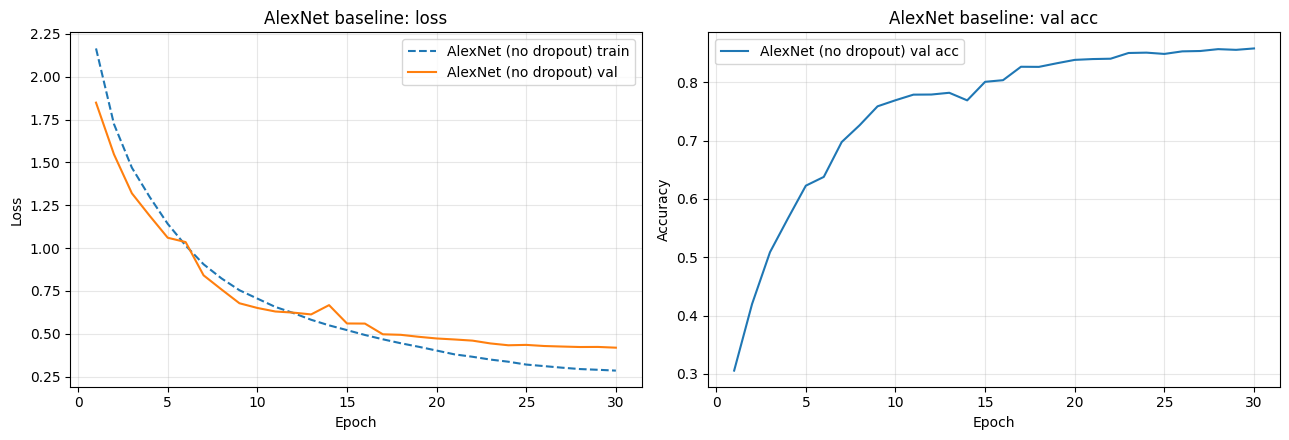

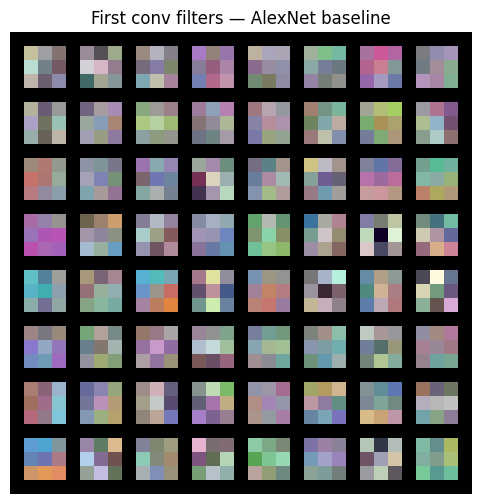

AlexNet baseline: TEST accuracy = 85.37%


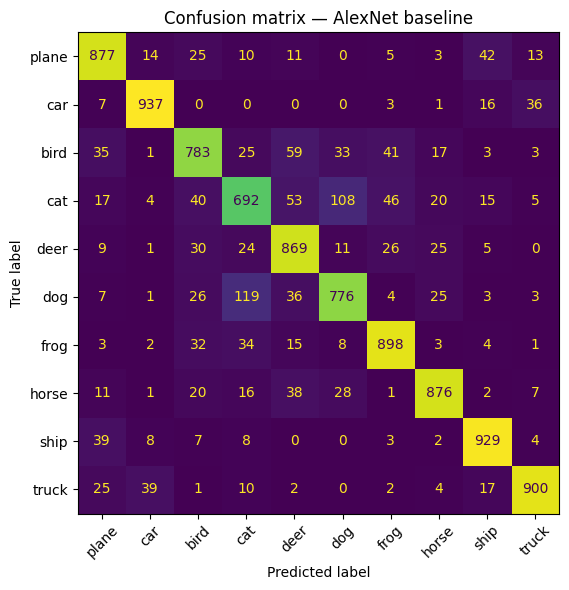

array([[877,  14,  25,  10,  11,   0,   5,   3,  42,  13],
       [  7, 937,   0,   0,   0,   0,   3,   1,  16,  36],
       [ 35,   1, 783,  25,  59,  33,  41,  17,   3,   3],
       [ 17,   4,  40, 692,  53, 108,  46,  20,  15,   5],
       [  9,   1,  30,  24, 869,  11,  26,  25,   5,   0],
       [  7,   1,  26, 119,  36, 776,   4,  25,   3,   3],
       [  3,   2,  32,  34,  15,   8, 898,   3,   4,   1],
       [ 11,   1,  20,  16,  38,  28,   1, 876,   2,   7],
       [ 39,   8,   7,   8,   0,   0,   3,   2, 929,   4],
       [ 25,  39,   1,  10,   2,   0,   2,   4,  17, 900]])

In [17]:
# ===== CELL 5 — Part A =====
alex, h_alex = train_model(ModifiedAlexNet(dropout=0.0), "AlexNet (no dropout)", lr=0.01)
plot_history([h_alex], "AlexNet baseline")
show_first_conv_filters(alex, "AlexNet baseline")
acc_alex = report_test(alex, "AlexNet baseline")
plot_confusion(alex, "AlexNet baseline")


=== AlexNet drop=0.3 | params=6,976,842 | epochs=30 | lr=0.01 ===
  ep 01/30 train_loss=2.247 acc=0.146 | val_loss=2.011 acc=0.257 | 16.6s
  ep 02/30 train_loss=1.778 acc=0.334 | val_loss=1.557 acc=0.420 | 17.4s
  ep 03/30 train_loss=1.511 acc=0.437 | val_loss=1.330 acc=0.507 | 16.6s
  ep 04/30 train_loss=1.330 acc=0.511 | val_loss=1.221 acc=0.563 | 16.4s
  ep 05/30 train_loss=1.166 acc=0.576 | val_loss=1.064 acc=0.623 | 16.7s
  ep 06/30 train_loss=1.041 acc=0.626 | val_loss=1.074 acc=0.623 | 16.5s
  ep 07/30 train_loss=0.941 acc=0.662 | val_loss=0.902 acc=0.683 | 17.5s
  ep 08/30 train_loss=0.863 acc=0.693 | val_loss=0.769 acc=0.719 | 16.8s
  ep 09/30 train_loss=0.788 acc=0.718 | val_loss=0.707 acc=0.749 | 17.4s
  ep 10/30 train_loss=0.739 acc=0.739 | val_loss=0.675 acc=0.759 | 16.6s
  ep 11/30 train_loss=0.691 acc=0.757 | val_loss=0.657 acc=0.765 | 16.9s
  ep 12/30 train_loss=0.653 acc=0.769 | val_loss=0.619 acc=0.787 | 16.8s
  ep 13/30 train_loss=0.610 acc=0.787 | val_loss=0.620 ac

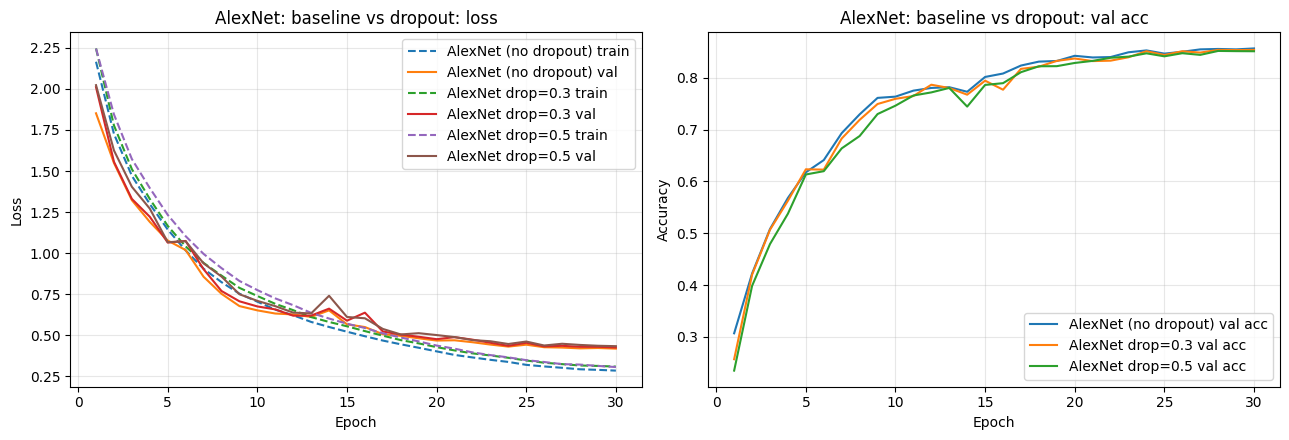

AlexNet drop=0.3: TEST accuracy = 85.73%
AlexNet drop=0.5: TEST accuracy = 85.36%
AlexNet (no dropout): final train=0.903 val=0.857 gap=0.046
AlexNet drop=0.3: final train=0.893 val=0.854 gap=0.039
AlexNet drop=0.5: final train=0.895 val=0.851 gap=0.044


In [11]:
# ===== CELL 6 — Part B: dropout =====
alex_d3,h_d3 = train_model(ModifiedAlexNet(dropout=0.3), "AlexNet drop=0.3", lr=0.01)
alex_d5,h_d5 = train_model(ModifiedAlexNet(dropout=0.5), "AlexNet drop=0.5", lr=0.01)
plot_history([h_alex,h_d3,h_d5], "AlexNet: baseline vs dropout")
report_test(alex_d3,"AlexNet drop=0.3"); report_test(alex_d5,"AlexNet drop=0.5")
for h in [h_alex,h_d3,h_d5]:
    print(f"{h['label']}: final train={h['train_acc'][-1]:.3f} val={h['val_acc'][-1]:.3f} gap={h['train_acc'][-1]-h['val_acc'][-1]:.3f}")


=== AlexNet + BatchNorm | params=6,979,146 | epochs=30 | lr=0.01 ===
  ep 01/30 train_loss=1.329 acc=0.516 | val_loss=1.129 acc=0.607 | 17.9s
  ep 02/30 train_loss=0.895 acc=0.685 | val_loss=1.036 acc=0.650 | 16.6s
  ep 03/30 train_loss=0.747 acc=0.739 | val_loss=0.814 acc=0.721 | 17.9s
  ep 04/30 train_loss=0.660 acc=0.770 | val_loss=0.636 acc=0.776 | 16.8s
  ep 05/30 train_loss=0.592 acc=0.793 | val_loss=0.625 acc=0.781 | 18.2s
  ep 06/30 train_loss=0.550 acc=0.808 | val_loss=0.689 acc=0.762 | 17.0s
  ep 07/30 train_loss=0.498 acc=0.826 | val_loss=0.642 acc=0.784 | 18.0s
  ep 08/30 train_loss=0.464 acc=0.839 | val_loss=0.507 acc=0.821 | 17.5s
  ep 09/30 train_loss=0.431 acc=0.850 | val_loss=0.474 acc=0.833 | 18.1s
  ep 10/30 train_loss=0.401 acc=0.860 | val_loss=0.516 acc=0.826 | 16.6s
  ep 11/30 train_loss=0.376 acc=0.869 | val_loss=0.467 acc=0.840 | 17.6s
  ep 12/30 train_loss=0.352 acc=0.877 | val_loss=0.446 acc=0.845 | 16.6s
  ep 13/30 train_loss=0.326 acc=0.887 | val_loss=0.429

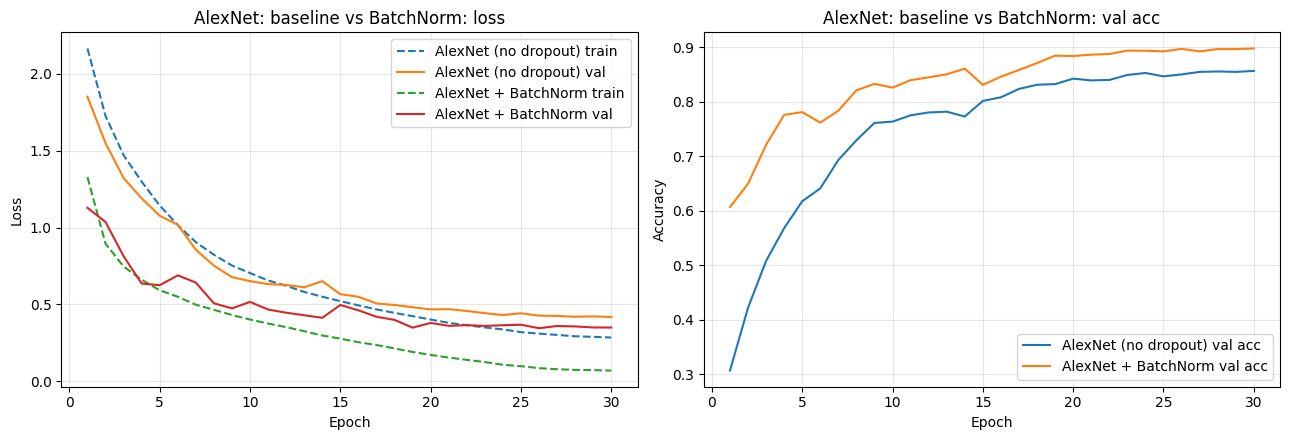

AlexNet + BatchNorm: TEST accuracy = 89.28%


0.8928

In [12]:
# ===== CELL 7 — Bonus: BatchNorm =====
alex_bn,h_bn = train_model(ModifiedAlexNet(dropout=0.0, use_bn=True), "AlexNet + BatchNorm", lr=0.01)
plot_history([h_alex,h_bn], "AlexNet: baseline vs BatchNorm")
report_test(alex_bn,"AlexNet + BatchNorm")